### Active cloaking extension from lattice to RGG and KNN 
The notebook implements potential theory-based active cloaking methods for detecting defects in random geometric graph. 

For later: 

active cloaking - hide anomalies/defects in networks by manipulating boundary measurements. 

Graph Laplacian 
Dirichlet Problem 
DTN map (Dirichlet-to-Neumann)

I use sparse matrix formats for memory efficiency. 

Green's function G solves: L·G = I (where L is Laplacian, I is identity)

Physically: G[i,j] = potential at node i when unit current injected at j

The RGG geenration is parameterized by z = (n-1)* pi *r^2 (approximates avg number of neighbors per node)

- Z is the expected mean degree in continuum limit
- n nodes randomly placed in unit square [0,1]^2
- connect nodes within radius r 

On the other hand, the KNN graph: 
The k-nearest neighbors graph (k-NNG) is a graph in which two vertices p and q are connected by an edge, if the distance between p and q is among the k-th smallest distances from p to other objects from P

Random Walk: start from vertex v, and then look at all vertices directly connected to it. if vi has d neighbors, then pick one uniformly at random with probability (1/d) and move there. The vertex we move to then bvecomes vi+1. Continue this process as many times as we want. The sequence v0, v1, v2... is the random walk. In network science, it reveals information and influence spreads.

So my two hypotheses are: 
1. effect of z on cloaking improvement for RGGs (Does network connectivity z affect how well cloaking hides defects?)
2. comparison of RGG vs KNN at matched mean degree (Does random vs. structured nearest-neighbor affect cloaking?)

note: the defect node is the middle index of the interior array

DeGiovanni, T., & Guevara Vasquez, F. (2025). A potential theory on weighted graphs. arXiv preprint arXiv:2405.07961v2. https://arxiv.org/abs/2405.07961

In [69]:
from __future__ import annotations
import math
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from typing import Tuple, List, Optional, Sequence
import random
import sys
import copy
import matplotlib.pyplot as plt


# convert 2D lattice coords into a single linear 1D array idx 
def idx_2d_to_linear(i: int, j: int, ny: int) -> int:
    return i * ny + j

#invert diagonal vectors (0^-1 is set to 0); isolated nodes have degree 0, inverting them would cause errors 
def safe_inv_diag(diagvec: np.ndarray) -> np.ndarray:
    inv = np.zeros_like(diagvec, dtype=float)
    nonzero = diagvec != 0
    inv[nonzero] = 1.0 / diagvec[nonzero]
    return inv


# for each node i, gather neighbor indices and transition probability p(i->j) 

def build_neighbor_probs_from_adj(A_csr: sp.csr_matrix):
    n = A_csr.shape[0]
    cvec = np.asarray(A_csr.sum(axis=1)).ravel()
    nbrs = [] # array of neighbor indices for each node
    probs = [] # array of transition probabilities for each node
    A = A_csr
    for i in range(n):
        row = A.getrow(i)
        cols = row.indices
        data = row.data.astype(float)
        if data.size == 0:   # node i is isolated
            nbrs.append(np.array([], dtype=int))
            probs.append(np.array([], dtype=float))
        else:
            denom = data.sum()  # total weight leaving node i 
            if denom == 0:
                p = np.zeros_like(data)  #all edges have weight 0 (shouldn't happen)
            else:
                p = data / denom  # normalize to get probabilites
            nbrs.append(cols.copy())
            probs.append(p.copy())
    return nbrs, probs, cvec

### Base Sparse Graph Class
Graph Laplacian L = D-A
D is the diagonal degree matrix (D[I,J] = sum of weights of edges incident to i) and A is the adjacency matrix. Diagonal Entries are negative. There is also a property: L.u = 0 for constant vectors u (sum of each row is 0)

This class stores the graph structure (adjacency matrix, laplacian), solves dirichlet boundary value problems (find interior potentials given boundary values), implements monte carlo random walk methods for approximate solutions, supports active cloaking (hides defects from boundary measurements using random walks) 
- direct solvers are here. They are exact solutions using G(matrix inversions)
- monte carlo method is probabilistic solutions via random walks
- the method random_walk_dirichlet() uses natural transition probabilities and perfect_cloak_mc() uses modified transition probabilities to hide anomalies

Note: I need to get G to solve for u. u = G.rhs. 
U is the potential at each node. Once I have u, i can compute currents (which flow proportional to viktage differences. 

For active cloacking, we need three things: 1. What the "normal" field looks like, 2. what it looks like with defect, and 3. what it looks like when we try to cloak. Will do the visualizations later 

I will then compute what the voltage field looks like in the normal no defect case (u_ref), what happens when there's a defect ie. voltage field gets disturbed (u_anom), 
what happens when I try to actively cloak/hide the defect(u_cloak), and finally compare them to see if the cloaking worked. I'd consider it working if u_cloack more or less same as ii_ref on exterior nodes  


In [71]:
class WeightedGraphSparse:
    def __init__(self, A_csr: sp.csr_matrix, B: Sequence[int]):
        self.A = A_csr.tocsr()  # adjacency matrix 
        self.nV = self.A.shape[0]  # of vertices
        self.V = np.arange(self.nV)   # array of all nodes
        self.B = np.array(sorted(set(B)), dtype=int) # array of boundary nodes; sorted and unique
        self.is_boundary = np.zeros(self.nV, dtype=bool)
        self.is_boundary[self.B] = True
        
        #laplacian
        degs = np.asarray(self.A.sum(axis=1)).ravel() #degree of each node
        self.Lap = (self.A - sp.diags(degs)).tocsc() #ull graph Laplacian (nV × nV) L = A - D (CSC for solving; its more efficient) 
        # neighbor probabilities (for MC)
        self.nbrs, self.probs, self.cvec = build_neighbor_probs_from_adj(self.A)
        
        # cache and compute once, reuse multiple times 
        self.G_sub = None  # Green's function on interior nodes (expensive to compute, so cache it)
        self.P = None
        self.Px = None
        self.Ar = None
        self.DTN = None  # Dirichlet-to-Neumann operator which maps boundary voltages to boundary currents

    # calculate transition matrix p for random walk (notes on p1 where I used this alternative formula)
    def compute_P_matrix_dense(self):
        diagL = self.Lap.diagonal()
        inv = safe_inv_diag(-diagL)
        DL = sp.diags(inv)
        P = (DL @ self.Lap + sp.eye(self.nV)).toarray()
        self.P = P
        return P
        
    #precompute and cache Green's function on interior nodes
    #(G is the inverse of the laplacian on interior nodes)
    # G[i,j] is the potential at interior node i when unit source at interior node j. u = G.rhs
    
    def precompute_greens_function(self):
        # get indices of all non boundary(interior nodes) as boundary potentials are fixed (Dirichlet condition)
        Vm = np.setdiff1d(self.V, self.B) 
        if Vm.size == 0:  # sanity check
            self.G_sub = np.zeros((0, 0))
            return
    
        n_interior = len(Vm)  # will use this to decide solution strategy
        
        Lap_vm = -self.Lap[Vm[:,None], Vm].tocsc() # (n_interior × n_interior) submatrix
    
    # direct inversion for small networks
        if n_interior < 1000:
            try:
                self.G_sub = np.linalg.inv(Lap_vm.toarray()) # convert sparse matrix to dense numpy array O(n^3)
                print(f"Cached dense G_sub: {n_interior}×{n_interior}")
                return
            except:
                pass
    
    # will fill in column-by-column; each column is the solution for one unit source location (which node we are injecting 1 unit of current into)
        G_sub = np.zeros((n_interior, n_interior))
        for k in range(n_interior):
            # unit source at interior node k
            rhs = np.zeros(n_interior)
            rhs[k] = 1.0  #inject 1 unit of current into k
            G_sub[:, k] = spla.spsolve(Lap_vm, rhs) 
    
        self.G_sub = G_sub # cache and store for future reuse 

    ## to do: use the full greens function 
    # rhs is the right hand side vector of length nV
    def green_solve_for_rhs(self, rhs: np.ndarray):
        Vm = np.setdiff1d(self.V, self.B) #extract interior nodes
        if Vm.size == 0:
            return np.zeros(self.nV)
    
        #use cached Green's function if available
        if self.G_sub is not None:
            rhs_vm = rhs[Vm] # extract only the interior nodes 
            # the full network is L·u = rhs and after extracting Vm: L_vm_vm · u_vm = rhs_vm (only solve this part)
            u_vm = self.G_sub @ rhs_vm  #fast
            u = np.zeros(self.nV, dtype=float)
            u[Vm] = u_vm
            return u
    
        #sparse solve
        Lap_vm = -self.Lap[Vm[:,None], Vm]
        rhs_vm = rhs[Vm]
        u_vm = spla.spsolve(Lap_vm.tocsc(), rhs_vm)
        u = np.zeros(self.nV, dtype=float)
        u[Vm] = u_vm
        return u

    # create restriction matrix R that extracts values from a subset of nodes (for extracting values from cloaking boundary)
    def compute_restriction(self, subset_idx: Sequence[int]):
        subset = np.array(subset_idx, dtype=int)
        R = sp.lil_matrix((self.nV, subset.size), dtype=int)
        for ii, node in enumerate(subset):
            R[node, ii] = 1
        return R.tocsr()

    # find  u[Vm] (potentials at interior nodes) given u[B] (potentials at boundary nodes) such that Laplace equation holds (dirichlet problem)
    def solve_dirichlet(self, u_boundary: np.ndarray) -> np.ndarray:
        u_b = np.asarray(u_boundary, dtype=float)
        Vm = np.setdiff1d(self.V, self.B)
        if Vm.size == 0:
            return u_b.copy()
    
        #extract Laplacian blocks; it represents how interior nodes influence each other
        L_vm_vm = self.Lap[Vm[:, None], Vm].tocsc()
        L_vm_b = self.Lap[Vm[:, None], self.B].toarray()
    
    
        # RHS
        rhs = -L_vm_b @ u_b[self.B]

        u_vm = spla.spsolve(L_vm_vm, rhs)
    
        u = np.zeros(self.nV, dtype=float)
        u[self.B] = u_b[self.B]
        u[Vm] = u_vm
        return u

    # monte carlo solution to the dirichlet problem using random walks; probabilistic interpretation of harmonic funtions 
    # disadv: need many samples for accuracy (computationally expensive) 
    # use binary search for ologn
    def random_walk_dirichlet(self, u_boundary: Sequence[float], Nrel: int = 1000, rng: Optional[random.Random] = None) -> np.ndarray:
        rng_local = rng or random.Random()
        u = np.asarray(u_boundary, dtype=float)
        cx = self.cvec  # total conductance
        u_mc = np.zeros(self.nV, dtype=float) #will accumulate charge across all random walks
        #precompute cumulative probabilities for neighbors
        cums = [np.cumsum(p) if p.size>0 else p for p in self.probs] 
        for _ in range(Nrel):
            for i in self.B:
                charge = u[i] * cx[i]
                u_mc[i] += charge
                if cums[i].size == 0: # skip if isolated
                    continue
                z = rng_local.random()
                jidx = int(np.searchsorted(cums[i], z, side='left'))
                if jidx >= len(self.nbrs[i]): 
                    jidx = len(self.nbrs[i]) - 1
                j = int(self.nbrs[i][jidx])
                while j not in self.B:  # continue until hitting boundary, absorb boundary condition 
                    u_mc[j] += charge   # accumulate charge at curr node
                    if cums[j].size == 0:
                        break
                    z = rng_local.random()
                    jidx = int(np.searchsorted(cums[j], z, side='left'))
                    if jidx >= len(self.nbrs[j]):
                        jidx = len(self.nbrs[j]) - 1
                    j = int(self.nbrs[j][jidx])
        denom = Nrel * cx
        out = np.zeros_like(u_mc)
        nz = denom != 0
        out[nz] = u_mc[nz] / denom[nz]
        return out

    def perfect_cloak_mc(self, u_boundary: Sequence[float], Nrel: int = 1000, rng: Optional[random.Random] = None) -> np.ndarray:
        rng_local = rng or random.Random()
        u = np.asarray(u_boundary, dtype=float)
        # use Ar for cx as in Julia
        if self.Ar is None:
            #fallback to regular cvec if Ar not computed
            cx = self.cvec
        else:
            cx = np.asarray(self.Ar.sum(axis=1)).ravel()
        u_mc = np.zeros(self.nV, dtype=float)
        #prepare cumulative for Px (dense)
        if self.Px is None:
            #if not available, fall back to standard random walk
            return self.random_walk_dirichlet(u_boundary, Nrel, rng_local)
        Px = self.Px
        cums_Px = np.cumsum(Px, axis=1)
        # for subsequent moves use neighbor probs and cums from self.probs
        cums = [np.cumsum(p) if p.size>0 else p for p in self.probs]
        for _ in range(Nrel):
            for i in self.B:
                charge = u[i] * (cx[i] if cx[i] != 0 else 0.0)
                u_mc[i] += charge
                # first jump sampled from Px row i
                z = rng_local.random()
                j = int(np.searchsorted(cums_Px[i], z, side='left'))
                if j >= self.nV:
                    j = self.nV - 1
                # then follow usual P random walk (neighbor lists)
                while j not in self.B:
                    u_mc[j] += charge
                    if len(cums[j]) == 0:
                        break
                    z = rng_local.random()
                    jidx = int(np.searchsorted(cums[j], z, side='left'))
                    if jidx >= len(self.nbrs[j]):
                        jidx = len(self.nbrs[j]) - 1
                    j = int(self.nbrs[j][jidx])
        denom = Nrel * cx
        out = np.zeros_like(u_mc)
        nz = denom != 0
        out[nz] = u_mc[nz] / denom[nz]
        # set Omega nodes to 0 if Omega is defined
        if hasattr(self, 'Omega') and self.Omega is not None:
            out[self.Omega] = 0.0
        return out

    #simulate adding a defect/anomaly to the graph by promoting an interior node to the boundary
    # defect is a fixed potential at an interior location. The method forces potential at that node to a specific value 
    # defecting is basically adding that node to the boundary set 
    def add_defect(self, defect_node: int):
        if defect_node in self.B:
            print(f"Node {defect_node} already a boundary node.")
            return self
            
        new_graph = copy.deepcopy(self) # so that defective vs. reference graph can be compared
        new_graph.B = np.unique(np.append(self.B, defect_node)) #defect_node now treated as boundary (fixed potential)
        
        # update the interior set. I is all nodes minus boundary node. defect_node is also removed from the interior
        new_graph.I = np.setdiff1d(self.V, new_graph.B)

        #recompute Laplacian and transition matrix
        A = new_graph.A
        degree = np.array(A.sum(axis=1)).flatten()
        L = sp.diags(degree) - A
        new_graph.Lap = L.tocsr()

        #update neighbor probabilities
        new_graph.nbrs, new_graph.probs, new_graph.cvec = build_neighbor_probs_from_adj(new_graph.A)

        #Green's function (restricted); now excludes the defect node and smaller than original interior (1 fewer node)
        Vm = np.setdiff1d(new_graph.V, new_graph.B)
        if Vm.size > 0:
            L_vm_vm = L[Vm[:, None], Vm].tocsc() #extract new interior L with defect_node removed from interior
            try:
                new_graph.G = sp.csr_matrix(spla.inv(L_vm_vm))
            except Exception:
                # fallback iterative approximation
                n = L_vm_vm.shape[0]
                I = sp.eye(n, format="csr")
                G_approx = np.zeros((n, n))
                for k in range(n):
                    e = np.zeros(n)
                    e[k] = 1.0
                    x, _ = spla.cg(L_vm_vm, e, rtol=1e-6, maxiter=500)
                    G_approx[:, k] = x
                new_graph.G = sp.csr_matrix(G_approx)

        #transition probability matrix P = D^{-1}A
        D_inv = sp.diags(1.0 / degree, format="csr")
        new_graph.P = D_inv @ A

        print(f"Added defect node {defect_node}; recomputed Laplacian and Green function.")
        return new_graph




The Graph Lattice Sparse class creates a 2D lattice with a designated cloaking region Ω and compute all the matrices needed for active cloaking using the DTN operator approach. 

In [73]:
class GraphLatticeSparse(WeightedGraphSparse):
    def __init__(self, nx_grid: int=11, ny_grid: int=11,
                 m1: Tuple[int,int]=(3,3), m2: Tuple[int,int]=(7,7),
                 random_weights: bool=True, rng: Optional[random.Random]=None):
        
        nx = int(nx_grid); ny = int(ny_grid) # grid dimension
        nV = nx * ny # total number of nodes 
        
        #build adjacency as sparse
        rows = []
        cols = []
        data = []

        # each node is connected to its four nearest neighbors (up, down, left, right) 
        # in the standard von Neumann neighborhood (which nodes can conduct current to each other)
        # sparse matrix A where A[u,v] = 1.0 if nodes u and v are neighbors
        
        for i in range(nx):
            for j in range(ny):
                u = idx_2d_to_linear(i,j,ny)
                # neighbors
                for (ii,jj) in ((i,j+1),(i,j-1),(i+1,j),(i-1,j)):
                    if 0 <= ii < nx and 0 <= jj < ny:
                        v = idx_2d_to_linear(ii,jj,ny)
                        rows.append(u); cols.append(v); data.append(1.0)
                        
        A = sp.csr_matrix((data,(rows,cols)), shape=(nV,nV))
        A = (A + A.T)/2
        
        # random weights (as it simulates real word situations better)
        rng_ocal = rng or random.Random()
        if random_weights:
            A = A.tolil()
            rows, cols = np.nonzero(A)
            for u,v in zip(rows, cols):
                if u < v and A[u,v] != 0:
                    w = 0.5 + rng_local.random()
                    A[u,v] = w; A[v,u] = w
            A = A.tocsr()
            
        # define boundary nodes by marking all nodes on the perimeter of the grid as boundary
        # I will apply boundary condition here later
        isboundary = np.zeros((nx, ny), dtype=bool)
        for i in range(nx):
            for j in range(ny):
                if i in [0, nx-1] or j in [0, ny-1]: #perimeter nodes
                    isboundary[i,j] = True

        
        B = np.nonzero(isboundary.reshape(-1))[0].tolist() #list of boundary node indices
        
        super().__init__(A_csr=A, B=B)
        #cloaking region
        m1x, m1y = m1; m2x, m2y = m2
        # compute partial Ω and Ω in linear indices
        dOmega_idx = [] #boundary of the cloaking region
        Omega_idx = [] # interior of the cloaking region
        
        for i in range(nx):
            for j in range(ny):
                #partial omega: edges of the rectangle not corners 
                cond1 = (i in [m1x, m2x] and (m1y+1 <= j <= m2y-1))  #left/right edge
                cond2 = (j in [m1y, m2y] and (m1x+1 <= i <= m2x-1)) # top bottom edge 
                if cond1 or cond2:
                    dOmega_idx.append(idx_2d_to_linear(i,j,ny))

                #strict interior 
                if (m1x+1 <= i <= m2x-1) and (m1y+1 <= j <= m2y-1):
                    Omega_idx.append(idx_2d_to_linear(i,j,ny))
                    
        self.partial_Omega = np.array(dOmega_idx, dtype=int)
        self.Omega = np.array(Omega_idx, dtype=int)
        self.nx = nx; self.ny = ny
        
        # precompute DTN, Lr, Px, Ar (all the matrices needed for active cloaking) 
        self._compute_DTN_Lr_Px_Ar()


    # the theory: Dirichlet-to-Neumann (DTN) operator maps boundary voltages to boundary currents 
    # while accounting for the interior region
    
    def _compute_DTN_Lr_Px_Ar(self):
        if self.partial_Omega.size == 0:
            self.DTN = sp.csr_matrix((0,0))
            self.Lr = self.Lap.copy()
            self.Px = None
            self.Ar = None
            return
        if self.Omega.size == 0:
            self.DTN = self.Lap[self.partial_Omega[:,None], self.partial_Omega].toarray()
            
        else:
            # extract four blocks of the laplacian based on regions
            L_d_d = self.Lap[self.partial_Omega[:,None], self.partial_Omega].toarray()
            L_d_O = self.Lap[self.partial_Omega[:,None], self.Omega].toarray()
            L_O_d = self.Lap[self.Omega[:,None], self.partial_Omega].toarray()
            L_O_O = self.Lap[self.Omega[:,None], self.Omega].toarray()
            if L_O_O.size == 0:
                middle = np.zeros_like(L_O_d)
            else: # Schur complement formula DTN = L_d_d - L_d_O · L_O_O^(-1) · L_O_d
                middle = np.linalg.solve(L_O_O, L_O_d)
            self.DTN = sp.csr_matrix(L_d_d - L_d_O @ middle)
            
        # Lr
        Lr = self.Lap.tocsc().copy()
        
        # replace connections between ∂Ω nodes with DTN values; this makes partial omega behave as if
        # the interior is removed but the effect is captured
        for i_idx, i in enumerate(self.partial_Omega):
            for j_idx, j in enumerate(self.partial_Omega):
                Lr[i, j] = self.DTN[i_idx, j_idx]
                
        # zero out rows/cols connecting Ω to rest and set Ω,Ω to zero
        others = np.setdiff1d(self.V, self.Omega)
        if self.Omega.size > 0 and others.size > 0:
            for o in others:
                for w in self.Omega:
                    Lr[o, w] = 0.0
                    Lr[w, o] = 0.0
            for w in self.Omega:
                Lr[w, w] = 0.0
                
        self.Lr = Lr.tocsc()
        
        # Px similar to P with diag from Lr
        diagLr = self.Lr.diagonal()
        inv = safe_inv_diag(-diagLr)
        DL = sp.diags(inv)
        self.Px = (DL @ self.Lr + sp.eye(self.nV)).toarray()
        # Ar
        Ar = self.Lr.tolil()
        for i in range(self.nV):
            Ar[i,i] = 0.0
        self.Ar = Ar.tocsr()

    # add defect node to the boundary set; its fixed at 0V
    def add_defect(self, defect_node: int) -> "GraphLatticeSparse":
        newA = self.A.copy()  # clone adjacency
        newB = np.unique(np.concatenate([self.B, np.array([defect_node], dtype=int)])).tolist()
        g = GraphLatticeSparse.__new__(GraphLatticeSparse)
        
        # initialize base class
        WeightedGraphSparse.__init__(g, newA, newB)
        # copy grid metadata
        
        g.partial_Omega = self.partial_Omega.copy()
        g.Omega = self.Omega.copy()
        g.nx = self.nx; g.ny = self.ny
        
        # recompute DTN etc
        g._compute_DTN_Lr_Px_Ar()
        return g

Graph construction for RGG and KNN
- Build adjacency for RGG from coordinates (n,2) using radius; symmetric, no self-loops.
- Build symmetric k-NN adjacency by connecting each node to its k nearest neighbors, then symmetrizing (so degrees can exceed k).

In [75]:
def rgg_adj_from_points(points: np.ndarray, radius: float) -> sp.csr_matrix:
    n = points.shape[0] # number of nodes
    
    # find neighbors using spatial search 
    nbr = NearestNeighbors(radius=radius, algorithm='auto').fit(points)
    neighs = nbr.radius_neighbors(points, return_distance=False) 
    # neighs[i] is array of indices of points within radius of point i
    
    rows = []
    cols = []
    data = []

    #build the edge list (all edges have weight 1.0)
    for i, arr in enumerate(neighs):
        for j in arr:
            if i != j:
                rows.append(i); cols.append(j); data.append(1.0)
   
    A = sp.csr_matrix((data, (rows, cols)), shape=(n, n))
    A = (A + A.T) / 2 #make symmetric (undirected)
    A.setdiag(0)     # remove diagonal entries 
    A.eliminate_zeros()
    return A.tocsr()

def knn_adj_from_points(points: np.ndarray, k: int) -> sp.csr_matrix:
    n = points.shape[0]

    # note: includes the point itself as neighbor #1 so indices[i] is arr of k+1 nearest neighbor indices for point i
    # the 1st entry is always itself 
    nbr = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(points)
    distances, indices = nbr.kneighbors(points)
    rows = []
    cols = []
    data = []

    #the edge list
    for i in range(n):
        for j in indices[i, 1:]:  # skip self 
            rows.append(i); cols.append(j); data.append(1.0)
    A = sp.csr_matrix((data, (rows, cols)), shape=(n, n))
    A = (A + A.T) / 2 #symmetrize
    A.setdiag(0)
    A.eliminate_zeros()
    return A.tocsr()



this class creates a random geometric graph cloaking implementation 
- degree parameter: z = (n-1) * pi * r^2. Solve for r
- n random points are uniform in unit square [0,1]^2
- Boundary B chosen as nodes near domain boundary (within margin)
- boundary B, interior Ω, and boundary layer ∂Ω
- Cloaking region chosen as nodes near center in radius r_in, ∂Ω an annulus

In [77]:
class RandomGeometricGraphPotential(WeightedGraphSparse):
    def __init__(self, n: int, z: float, rng_seed: Optional[int]=None):
        rng = np.random.RandomState(rng_seed) #random point generation
        points = rng.rand(n, 2)

        # calculate connection radius 
        r = math.sqrt(z / ((n-1) * math.pi))
        A = rgg_adj_from_points(points, r) # connects all nodes if they're within the distance r 

        # choose B nodes within margin from boundary (distance to edges < boundary_margin)
        margin = 0.08  # tunable
        isboundary = np.logical_or.reduce((points[:,0] < margin, points[:,0] > 1-margin,
                                           points[:,1] < margin, points[:,1] > 1-margin))
        
        B = np.nonzero(isboundary)[0].tolist()
        super().__init__(A.tocsr(), B)
        self.points = points
        
        # define Omega as nodes within r_in from center
        center = np.array([0.5, 0.5])
       
        r_in = 0.08 #inner radius Ω interior
        r_out = 0.12 # outer radius ∂Ω boundary
        
        dists = np.linalg.norm(points - center[None,:], axis=1) # dist from center
        
        self.Omega = np.nonzero(dists <= r_in)[0] # interior cloaking region 

        # boundary layer: distance between r_in and 0.12 from center
        self.partial_Omega = np.nonzero((dists > r_in) & (dists <= r_out))[0]
        self._compute_DTN_Lr_Px_Ar
        
    #implementation of the active cloaking strategy from the paper
    def _compute_DTN_Lr_Px_Ar(self):
        partial = self.partial_Omega #boundary of the cloaking region delta Ω
        Omega = self.Omega # interior of the cloaking region Ω
        
        if partial.size == 0: #edge case 
            self.DTN = sp.csr_matrix((0,0))
            self.Lr = self.Lap.copy()
            self.Px = None
            self.Ar = None
            return
            
        if Omega.size == 0: 
            self.DTN = self.Lap[partial[:,None], partial].toarray()
            
        else: #Schur Complement (TODO: read more about it) 
            L_d_d = self.Lap[partial[:,None], partial].toarray()
            L_d_O = self.Lap[partial[:,None], Omega].toarray()
            L_O_d = self.Lap[Omega[:,None], partial].toarray()
            L_O_O = self.Lap[Omega[:,None], Omega].toarray()
            
            if L_O_O.size == 0:
                middle = np.zeros_like(L_O_d)
            else:
                middle = np.linalg.solve(L_O_O, L_O_d)
            self.DTN = sp.csr_matrix(L_d_d - L_d_O @ middle)
       
        # for me later: THE MATH FROM THE PAPER: DTN = L_d_d - L_d_O · L_O_O^(-1) · L_O_d
       
        # Lr: ∂Ω nodes now interact via DTN instead of direct connections
        Lr = self.Lap.tocsc().copy()
        for i_idx,i in enumerate(partial):
            for j_idx,j in enumerate(partial):
                Lr[i,j] = self.DTN[i_idx,j_idx]

        # disconnect Ω drom rest of the network 
        others = np.setdiff1d(self.V, Omega) #everything except omega
        if Omega.size > 0 and others.size > 0:
            for o in others:
                for w in Omega:
                    Lr[o,w] = 0.0 #no connection from exterior to Ω
                    Lr[w,o] = 0.0 #no connection from Ω to exterior
            for w in Omega:
                Lr[w,w] = 0.0
                
        #modified transition matrix
        #same formula as regular P, but using Lr; Px = D_Lr^(-1) · Lr + I
        
        self.Lr = Lr.tocsc()
        diagLr = self.Lr.diagonal()
        inv = safe_inv_diag(-diagLr)
        DL = sp.diags(inv)
        
        self.Px = (DL @ self.Lr + sp.eye(self.nV)).toarray()

        # build adjacency from Lr
        Ar = self.Lr.tolil()
        for i in range(self.nV):
            Ar[i,i] = 0.0
        self.Ar = Ar.tocsr()

    def add_defect(self, defect_node: int) -> "RandomGeometricGraphPotential":
        newA = self.A.copy() # copy and modify
        newB = np.unique(np.concatenate([self.B, np.array([defect_node], dtype=int)])).tolist()
        g = RandomGeometricGraphPotential.__new__(RandomGeometricGraphPotential)
        WeightedGraphSparse.__init__(g, newA, newB)
        g.points = self.points.copy()
        g.partial_Omega = self.partial_Omega.copy()
        g.Omega = self.Omega.copy()
        g._compute_DTN_Lr_Px_Ar()
        return g

In [79]:
class KNNGraphPotential(WeightedGraphSparse):
    def __init__(self, n: int, k_target: int, rng_seed: Optional[int]=None):
        rng = np.random.RandomState(rng_seed)
        points = rng.rand(n, 2)
        A = knn_adj_from_points(points, k_target)
        #boundary chosen as near edges
        margin = 0.08
        isboundary = np.logical_or.reduce((points[:,0] < margin, points[:,0] > 1-margin,
                                           points[:,1] < margin, points[:,1] > 1-margin))
        B = np.nonzero(isboundary)[0].tolist()
        super().__init__(A.tocsr(), B)
        self.points = points
        center = np.array([0.5,0.5])
        
        r_in = 0.08; 
        r_out = 0.12
        
        dists = np.linalg.norm(points - center[None,:], axis=1)
        self.Omega = np.nonzero(dists <= r_in)[0]
        self.partial_Omega = np.nonzero((dists > r_in) & (dists <= r_out))[0]
        # compute DTN etc
        self._compute_DTN_Lr_Px_Ar()

    def _compute_DTN_Lr_Px_Ar(self):
        #same code as RGG
        partial = self.partial_Omega
        Omega = self.Omega
        if partial.size == 0:
            self.DTN = sp.csr_matrix((0,0))
            self.Lr = self.Lap.copy()
            self.Px = None
            self.Ar = None
            return
        if Omega.size == 0:
            self.DTN = self.Lap[partial[:,None], partial].toarray()
        else:
            L_d_d = self.Lap[partial[:,None], partial].toarray()
            L_d_O = self.Lap[partial[:,None], Omega].toarray()
            L_O_d = self.Lap[Omega[:,None], partial].toarray()
            L_O_O = self.Lap[Omega[:,None], Omega].toarray()
            if L_O_O.size == 0:
                middle = np.zeros_like(L_O_d)
            else:
                middle = np.linalg.solve(L_O_O, L_O_d)
            self.DTN = sp.csr_matrix(L_d_d - L_d_O @ middle)
        Lr = self.Lap.tocsc().copy()
        for i_idx,i in enumerate(partial):
            for j_idx,j in enumerate(partial):
                Lr[i,j] = self.DTN[i_idx,j_idx]
        others = np.setdiff1d(self.V, Omega)
        if Omega.size > 0 and others.size > 0:
            for o in others:
                for w in Omega:
                    Lr[o,w] = 0.0
                    Lr[w,o] = 0.0
            for w in Omega:
                Lr[w,w] = 0.0
        self.Lr = Lr.tocsc()
        diagLr = self.Lr.diagonal()
        inv = safe_inv_diag(-diagLr)
        DL = sp.diags(inv)
        self.Px = (DL @ self.Lr + sp.eye(self.nV)).toarray()
        Ar = self.Lr.tolil()
        for i in range(self.nV):
            Ar[i,i] = 0.0
        self.Ar = Ar.tocsr()

    def add_defect(self, defect_node: int) -> "KNNGraphPotential":
        newA = self.A.copy()
        newB = np.unique(np.concatenate([self.B, np.array([defect_node], dtype=int)])).tolist()
        g = KNNGraphPotential.__new__(KNNGraphPotential)
        WeightedGraphSparse.__init__(g, newA, newB)
        g.points = self.points.copy()
        g.partial_Omega = self.partial_Omega.copy()
        g.Omega = self.Omega.copy()
        g._compute_DTN_Lr_Px_Ar()
        return g

the following function measures how much does active cloaking reduce the observable disturbance caused by an anomaly
- u_ref: reference voltage field (no anomaly, no cloaking)
- u_anom: anomalous voltage field (with defect, no cloaking)
- u_cloak: cloaked voltage field (with defect and active cloaking)
- ext_idx: exterior measurement indice

In [81]:
def cloaking_metric_ref_vs_cloak(u_ref: np.ndarray, u_anom: np.ndarray, u_cloak: np.ndarray, ext_idx: np.ndarray) -> float:
    diff_anom = u_anom[ext_idx] - u_ref[ext_idx]
    diff_cloak = u_cloak[ext_idx] - u_ref[ext_idx]
    n1 = np.linalg.norm(diff_anom)
    n2 = np.linalg.norm(diff_cloak)
    return float(n1 - n2)

Visualization 

In [83]:
def visualize_graph_potential(graph, defect_node=None, title="Visualize RGG & kNN graph with color-coded regions"):
    points = getattr(graph, "points", None)
    if points is None:
        raise ValueError("Graph must have 'points' attribute for visualization.")
    
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    
    # Draw edges
    rows, cols = graph.A.nonzero()
    for i, j in zip(rows, cols):
        if i < j:
            xi, yi = points[i]
            xj, yj = points[j]
            plt.plot([xi, xj], [yi, yj], color='lightgray', lw=0.4, zorder=1)
    
    # Plot Ω region (interior)
    if hasattr(graph, "Omega") and len(graph.Omega) > 0:
        plt.scatter(points[graph.Omega, 0], points[graph.Omega, 1],
                    color="red", s=40, label="Ω (cloaked interior)", zorder=3)
    
    # Plot ∂Ω region (partial boundary)
    if hasattr(graph, "partial_Omega") and len(graph.partial_Omega) > 0:
        plt.scatter(points[graph.partial_Omega, 0], points[graph.partial_Omega, 1],
                    color="orange", s=35, label="∂Ω (partial boundary)", zorder=3)
    
    # Plot boundary nodes
    plt.scatter(points[graph.B, 0], points[graph.B, 1],
                color="blue", s=25, label="Boundary B", zorder=3)
    
    # Plot interior (non-boundary, non-Omega) nodes
    interior = np.setdiff1d(graph.V, np.concatenate([graph.B, graph.Omega, graph.partial_Omega]))
    plt.scatter(points[interior, 0], points[interior, 1],
                color="gray", s=15, label="Interior", zorder=2)
    
    # Plot defect node if any
    if defect_node is not None:
        plt.scatter(points[defect_node, 0], points[defect_node, 1],
                    color="black", s=80, marker="x", label="Defect node", zorder=4)
    
    plt.title(title, fontsize=13)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc="upper right", fontsize=8)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()



Run tests:
- test RGG cloaking at different connectivity levels (varying z)
- compare RGG vs kNN at matched mean degree

Experiment: n = 600 MC trials = 10000

RGG test for z = 10.0
defect node index: 170


/Users/raheesikder/Library/Python/3.12/lib/python/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


z=10.0 Δ_cloak=0.046618 (time 22.75s)

RGG test for z = 20.0
defect node index: 170


/Users/raheesikder/Library/Python/3.12/lib/python/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


z=20.0 Δ_cloak=0.196276 (time 29.99s)

RGG test for z = 30.0
defect node index: 170


/Users/raheesikder/Library/Python/3.12/lib/python/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


z=30.0 Δ_cloak=0.340322 (time 31.58s)

Compare RGG vs kNN at matched mean degree
RGG mean degree:  18.276666666666667
Using k = 18 for kNN graph


/Users/raheesikder/Library/Python/3.12/lib/python/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


RGG metric Δ_cloak: 0.44292222168713447
kNN metric Δ_cloak: 0.2591198913878292

results: 
RGG z=10.0: Δ_cloak=0.046618, time=22.75s
RGG (z=10.0) Δ_cloak = 0.442922
kNN (k=18) Δ_cloak = 0.259120
RGG z=20.0: Δ_cloak=0.196276, time=29.99s
RGG (z=20.0) Δ_cloak = 0.442922
kNN (k=18) Δ_cloak = 0.259120
RGG z=30.0: Δ_cloak=0.340322, time=31.58s
RGG (z=30.0) Δ_cloak = 0.442922
kNN (k=18) Δ_cloak = 0.259120


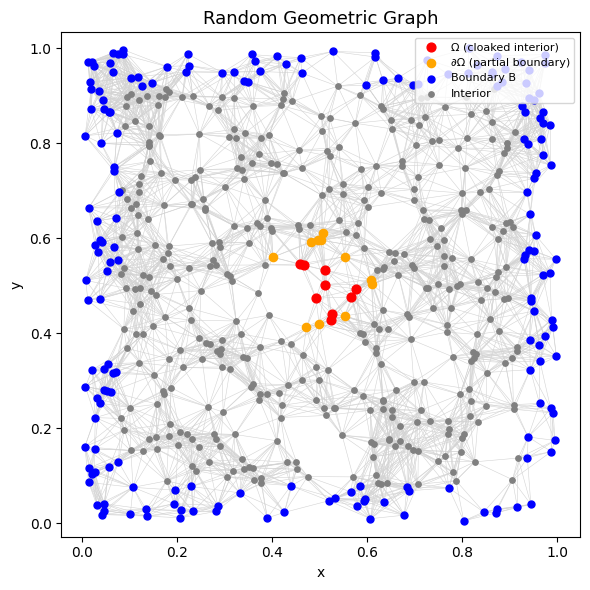

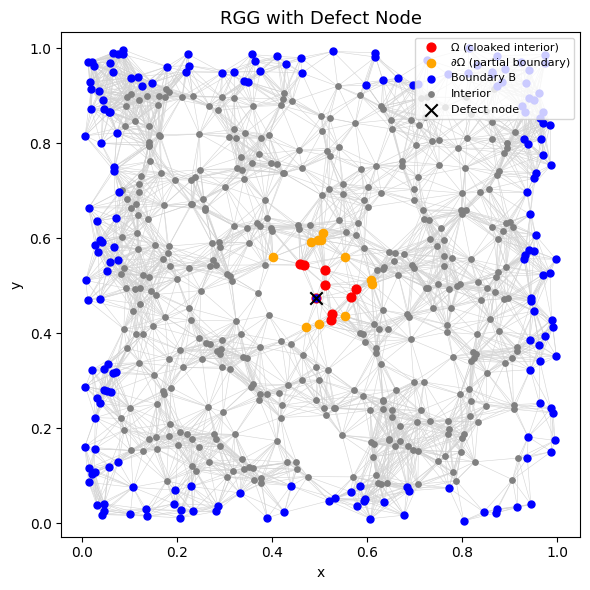

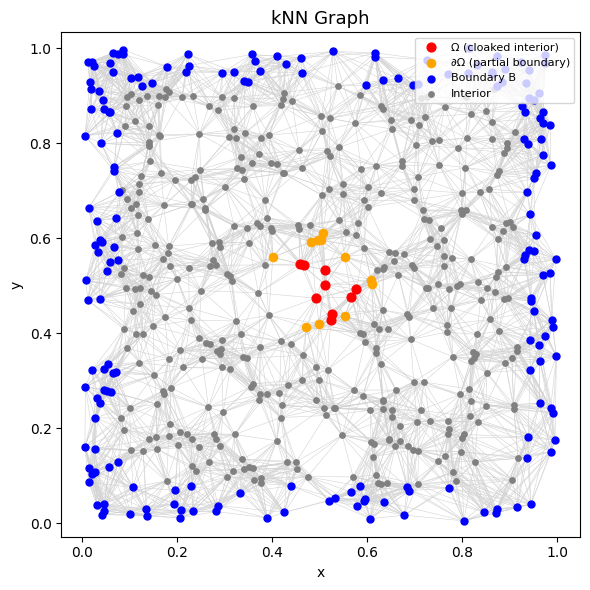

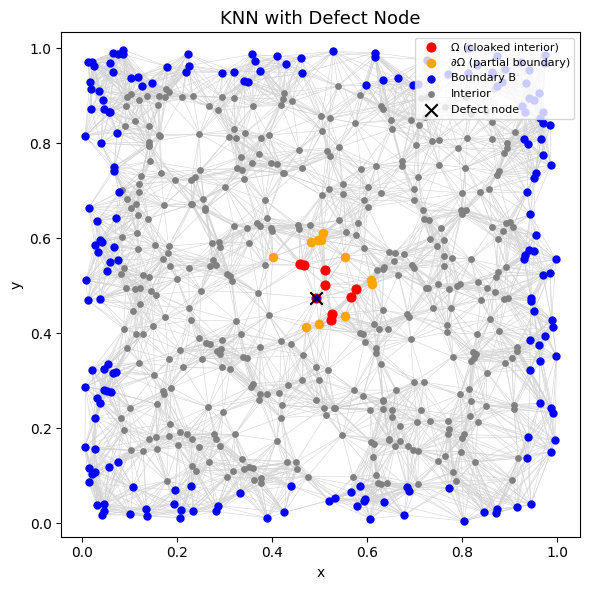

In [94]:
def main():

    random_seed = 42
    rng = random.Random(random_seed)
    np.random.seed(random_seed)

    # experiment parameters (tweakable)
    n = 600  # number of nodes 

    # test 3 connectivitiy level (sparse graph, medium density, dense graph) 
    z_values = [10.0, 20.0, 30.0]   # mean-degree 
    
    n_trials_mc = 10000       # Monte Carlo repetitions (the paper use 5000+)
    print("Experiment: n =", n, "MC trials =", n_trials_mc)

    # boundary Dirichlet boundary data f: set B nodes to 0 for bottom margin and 2 for top margin (approx)
    # i will set boundary values according to y coordinate threshold for RGG/kNN objects individually later

    # part a: RGG varying z
    results_rgg = []
    for z in z_values:
        print(f"\nRGG test for z = {z}")
        t0 = time.time() #timer for performance measurement 
        rg = RandomGeometricGraphPotential(n=n, z=z, rng_seed=random_seed)
        
        # build a plausible boundary potential f: use y coordinate of points to assign potentials
        f = np.zeros(rg.nV)
        f_vals = 2.0 * rg.points[:,1]  #potential proportional to y
        f[:] = f_vals  #full vector, solver only uses B entries
        
        # reference solution (no anomaly)
        u_ref = rg.solve_dirichlet(f)
        
        # anomaly: pick a node in Omega to be a defective Dirichlet 0 (if none, pick center closest node)
        if rg.Omega.size > 0:
            defect = int(rg.Omega[len(rg.Omega)//2])
        else:
            # pick node closest to center
            center = np.array([0.5,0.5])
            dists = np.linalg.norm(rg.points - center[None,:], axis=1)
            defect = int(np.argmin(dists))
            
        print("defect node index:", defect)
        
        #create modified graph with defect (promote it to boundary)
        rg_def = rg.add_defect(defect)
        
        #boundary potentials for anomalous solve: use same f but with defect node set to 0
        f_anom = f.copy()
        f_anom[defect] = 0.0
        u_anom = rg_def.solve_dirichlet(f_anom)
       
        # now attempt to cloak: use rg_def.perfect_cloak_mc? mimic Julia: we call perfect_cloak on rg_def
        # with boundary values equal to u_ref at B of rg (approx)
        # We'll run cloak MC on the modified graph rg_def and then compare exterior values against u_ref
        # Use boundary potentials equal to u_ref at the modified graph's B nodes (rg_def.B)
       
        u_boundary_for_cloak = np.zeros(rg_def.nV)
        
        # set boundary vector to u_ref for nodes in rg_def.B if in u_ref else 0
        for b in rg_def.B:
            u_boundary_for_cloak[b] = u_ref[b]
        
        u_cloak_mc = rg_def.perfect_cloak_mc(u_boundary_for_cloak, Nrel=n_trials_mc, rng=random.Random(random_seed+1))
        
        # measurement set ext = nodes not in Omega (complement)
        ext_idx = np.setdiff1d(rg.V, rg.Omega)
        metric = cloaking_metric_ref_vs_cloak(u_ref, u_anom, u_cloak_mc, ext_idx)
        t1 = time.time()
        print(f"z={z} Δ_cloak={metric:.6f} (time {t1-t0:.2f}s)")
        results_rgg.append((z, metric, t1-t0))

    # part B: compare RGG vs kNN at matched mean degree
    # For each z pick mean degree from an RGG realization and then build kNN with k ~ mean_deg.
    print("\nCompare RGG vs kNN at matched mean degree")
   
    z_comparison = 20.0
    
    #build RGG
    rg = RandomGeometricGraphPotential(n=n, z=z_comparison, rng_seed=random_seed)
    mean_deg = float(np.asarray(rg.A.sum(axis=1)).ravel().mean())
    print("RGG mean degree: ", mean_deg)
    
    #choose k as nearest integer (based on rgg mean degree)
    k = max(1, int(round(mean_deg)))
    print("Using k =", k, "for kNN graph")
    
    # build graphs
    knn = KNNGraphPotential(n=n, k_target=k, rng_seed=random_seed)
    
    #choose boundary potential f based on y coordinate (same approach)
    f_rgg = 2.0 * rg.points[:,1]
    u_ref_rgg = rg.solve_dirichlet(f_rgg)
   
    #pick defect node in rg (center)
    if rg.Omega.size>0:
        defect_rg = int(rg.Omega[len(rg.Omega)//2])
    else:
        dists = np.linalg.norm(rg.points - np.array([0.5,0.5])[None,:], axis=1)
        defect_rg = int(np.argmin(dists))
    rg_def = rg.add_defect(defect_rg)
    f_anom = f_rgg.copy(); f_anom[defect_rg] = 0.0
    u_anom_rg = rg_def.solve_dirichlet(f_anom)
    
    #cloak MC for rg_def
    u_boundary_for_cloak = np.zeros(rg_def.nV)
    for b in rg_def.B: u_boundary_for_cloak[b] = u_ref_rgg[b]
    u_cloak_rg = rg_def.perfect_cloak_mc(u_boundary_for_cloak, Nrel=n_trials_mc, rng=random.Random(random_seed+2))
    ext_idx_rg = np.setdiff1d(rg.V, rg.Omega)
    metric_rg = cloaking_metric_ref_vs_cloak(u_ref_rgg, u_anom_rg, u_cloak_rg, ext_idx_rg)
    print("RGG metric Δ_cloak:", metric_rg)

    #for kNN graph, using same f definition but using knn.points
    f_knn = 2.0 * knn.points[:,1]
    u_ref_knn = knn.solve_dirichlet(f_knn)
   
    #choose defect in knn in the same way
    if knn.Omega.size>0:
        defect_knn = int(knn.Omega[len(knn.Omega)//2])
    else:
        dists = np.linalg.norm(knn.points - np.array([0.5,0.5])[None,:], axis=1)
        defect_knn = int(np.argmin(dists))
    knn_def = knn.add_defect(defect_knn)
    f_anom_knn = f_knn.copy(); f_anom_knn[defect_knn] = 0.0
    u_anom_knn = knn_def.solve_dirichlet(f_anom_knn)
    u_boundary_for_cloak_knn = np.zeros(knn_def.nV)
    for b in knn_def.B: u_boundary_for_cloak_knn[b] = u_ref_knn[b]
    u_cloak_knn = knn_def.perfect_cloak_mc(u_boundary_for_cloak_knn, Nrel=n_trials_mc, rng=random.Random(random_seed+3))
    ext_idx_knn = np.setdiff1d(knn.V, knn.Omega)
    metric_knn = cloaking_metric_ref_vs_cloak(u_ref_knn, u_anom_knn, u_cloak_knn, ext_idx_knn)
    print("kNN metric Δ_cloak:", metric_knn)

    print("\nresults: ")
    for (z, metric, t) in results_rgg:
        print(f"RGG z={z}: Δ_cloak={metric:.6f}, time={t:.2f}s")
        print(f"RGG (z={z}) Δ_cloak = {metric_rg:.6f}")
        print(f"kNN (k={k}) Δ_cloak = {metric_knn:.6f}")

   
    visualize_graph_potential(rg, title="Random Geometric Graph")
    visualize_graph_potential(rg_def, defect_node=defect, title="RGG with Defect Node")
    visualize_graph_potential(knn, title="kNN Graph")
    visualize_graph_potential(knn_def, defect_node=defect, title="KNN with Defect Node")

if __name__ == "__main__":
    main()

My Interpretetions 

The results show a relationship between the connectivity parameter z and the cloaking improvement in RGGs. As z increases from 10 to 30, the Δ_cloak metric increases proportionally as it rises from 0.0466 to 0.3403. It shows that denser graphs will have better cloaking performance, which makes sense intuitively as higher mean degree implies better diffusion of potential across the network, which helps restore boundary-level uniformity even when a defect is introduced. Stronger connectivity improves the network’s ability to “mask” interior perturbations. 

When comparing RGG and kNN graphs at matched mean degrees (around 18), the RGG achieves a substantially higher Δ_cloak (0.44) than the kNN graph (0.26). Both graphs have similar average degrees, so it could be because RGGs have local geometric continuity, but kNN graphs enforce connectivity more rigidly. 
(It seems counter intuitive to me, as I expected KNN to have better performance) 